# Phase 1: Exploratory Data Analysis

This notebook explores the MovieLens 100k dataset to understand its characteristics and inform our recommendation system design.

## 1. Setup and Imports

Import necessary libraries and set up paths

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

## 2. Load Data

Load all MovieLens 100k files:
- u.data: User ratings
- u.item: Movie metadata
- u.user: User demographics
- u.genre: Genre list

In [2]:
def load_movieLens_data(data_path):
    user_movie_ratings = pd.read_csv(
        os.path.join(data_path, 'u.data'),
        sep='\t',
        names=['user_id', 'movie_id', 'rating', 'timestamp'],
        encoding='latin-1'
    )
    users_details = pd.read_csv(
        os.path.join(data_path, 'u.user'),
        sep='|',
        names=['user_id', 'age', 'gender', 'occupation', 'zip_code'],
        encoding='latin-1'
    )
    movies_details = pd.read_csv(
        os.path.join(data_path, 'u.item'),
        sep='|',
        names=['movie_id', 'title', 'release_date', 'video_release_date', 'IMDb_URL', 'unknown', 'Action', 'Adventure', 'Animation', 'Childrens', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'],
        encoding='latin-1'
    )
    genre_list = pd.read_csv(
        os.path.join(data_path, 'u.genre'),
        sep='|',
        names=['genre_id', 'genre_name'],
        encoding='latin-1'
    )
    users_occupations = pd.read_csv(
        os.path.join(data_path, 'u.occupation'),
        sep='|',
        names=['user_id', 'occupation'],
        encoding='latin-1'
    )
    return user_movie_ratings, users_details, movies_details, genre_list, users_occupations

DATA_PATH = '/Users/sanedara/Documents/Machine_learning_practise/recommendation_system/data/ml-100k/'
user_movie_ratings, users_details, movies_details, genre_list, users_occupations = load_movieLens_data(DATA_PATH)



## 3. Dataset Overview

Basic statistics:
- Number of users, movies, ratings
- Data types and missing values
- Date range of ratings

In [3]:
print(f"Number of users: {len(user_movie_ratings['user_id'].unique())}")
print(f"Number of movies: {len(user_movie_ratings['movie_id'].unique())}")
print(f"Number of ratings: {len(user_movie_ratings)}")

Number of users: 943
Number of movies: 1682
Number of ratings: 100000


## 4. Rating Distribution Analysis

- Distribution of ratings (1-5)
- Average rating per user
- Average rating per movie
- Rating frequency over time

User rating statistics:
     user_id  avg_rating  std_rating  num_ratings  min_rating  max_rating
0          1    3.610294    1.263585          272           1           5
1          2    3.709677    1.030472           62           1           5
2          3    2.796296    1.219026           54           1           5
3          4    4.333333    0.916831           24           2           5
4          5    2.874286    1.362963          175           1           5
..       ...         ...         ...          ...         ...         ...
938      939    4.265306    0.974156           49           2           5
939      940    3.457944    1.012007          107           1           5
940      941    4.045455    0.898532           22           2           5
941      942    4.265823    0.763072           79           2           5
942      943    3.410714    1.258886          168           1           5

[943 rows x 6 columns]
users who rate everything 5: 0
users who rate everything 1: 0
us

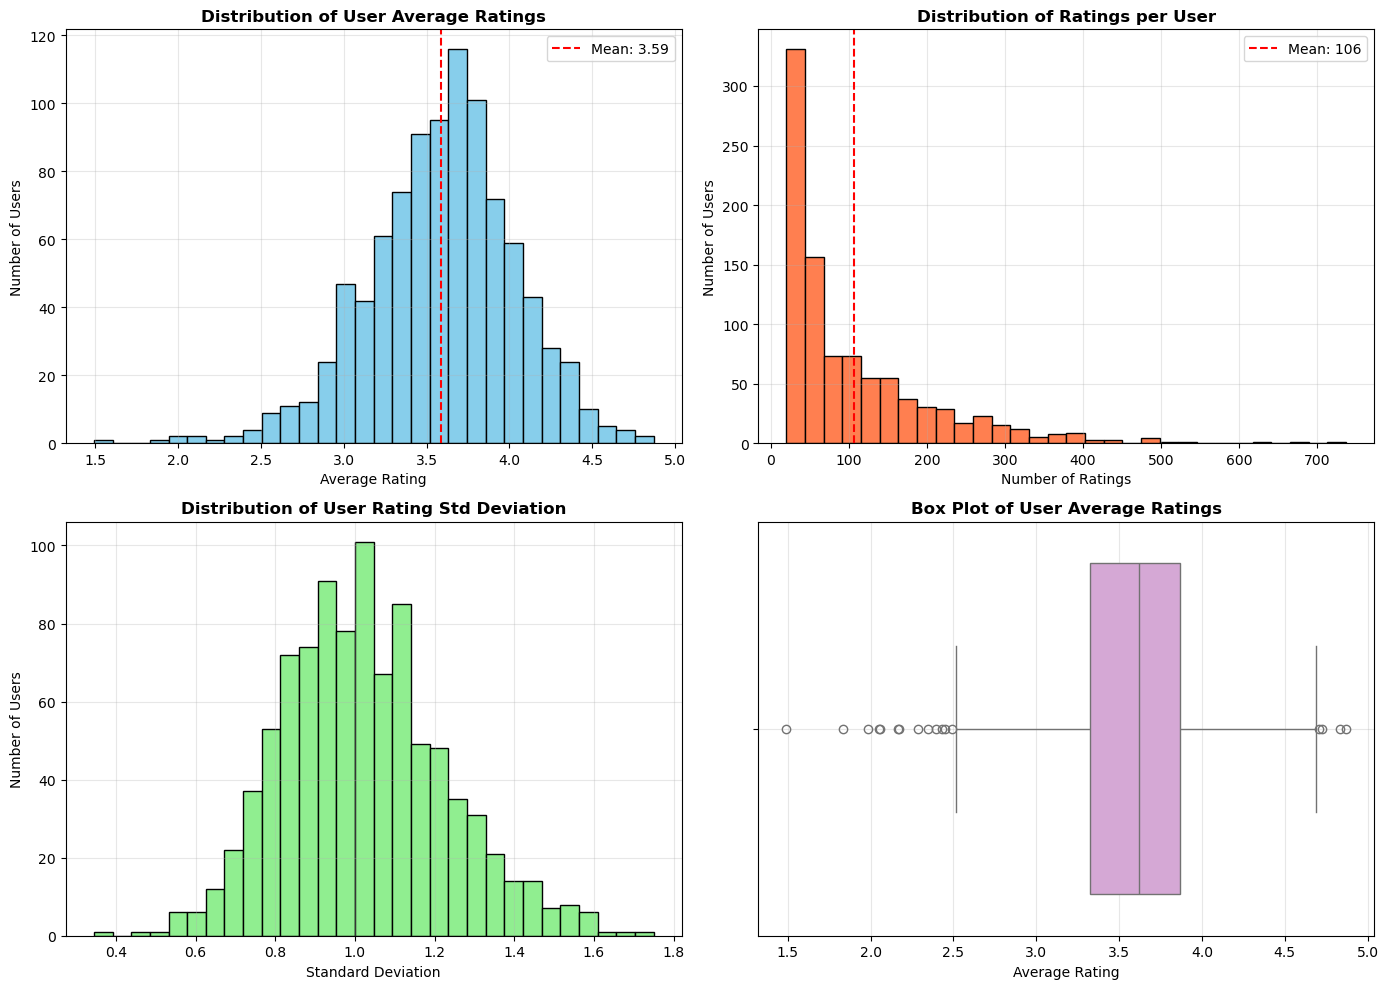

In [26]:
import seaborn as sns
# user_movie_ratings['rating'].value_counts().sort_index().plot(kind='bar')
# plt.title('Rating Distribution')
# plt.xlabel('Rating')
# plt.ylabel('Count')
# plt.show()

# print(f"Average rating: {user_movie_ratings['rating'].mean()}")
# print(f"Median rating: {user_movie_ratings['rating'].median()}")
# print(f"Standard deviation: {user_movie_ratings['rating'].std()}")
# print(f"Descriptive statistics: {user_movie_ratings['rating'].describe()}")

user_stats = user_movie_ratings.groupby('user_id')['rating'].agg(['mean', 'std', 'count', 'min', 'max']).reset_index()
user_stats_columns = ['user_id', 'avg_rating', 'std_rating', 'num_ratings', 'min_rating', 'max_rating']
user_stats.columns = user_stats_columns

print('User rating statistics:')
print(user_stats)

print(f"users who rate everything 5: {(user_stats['min_rating'] == 5).sum()}")
print(f"users who rate everything 1: {(user_stats['max_rating'] == 1).sum()}")
print(f"users who rate more than 4: {(user_stats['avg_rating'] >= 4).sum()}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Distribution of average ratings per user
axes[0, 0].hist(user_stats['avg_rating'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].axvline(user_stats['avg_rating'].mean(), color='red', linestyle='--', 
                   label=f"Mean: {user_stats['avg_rating'].mean():.2f}")
axes[0, 0].set_title('Distribution of User Average Ratings', fontweight='bold')
axes[0, 0].set_xlabel('Average Rating')
axes[0, 0].set_ylabel('Number of Users')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)


# Distribution of rating counts per user
axes[0, 1].hist(user_stats['num_ratings'], bins=30, color='coral', edgecolor='black')
axes[0, 1].axvline(user_stats['num_ratings'].mean(), color='red', linestyle='--',
                   label=f"Mean: {user_stats['num_ratings'].mean():.0f}")
axes[0, 1].set_title('Distribution of Ratings per User', fontweight='bold')
axes[0, 1].set_xlabel('Number of Ratings')
axes[0, 1].set_ylabel('Number of Users')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Distribution of std deviation per user
axes[1, 0].hist(user_stats['std_rating'].dropna(), bins=30, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Distribution of User Rating Std Deviation', fontweight='bold')
axes[1, 0].set_xlabel('Standard Deviation')
axes[1, 0].set_ylabel('Number of Users')
axes[1, 0].grid(alpha=0.3)

# Box plot of user averages
sns.boxplot(x=user_stats['avg_rating'], ax=axes[1, 1], color='plum')
axes[1, 1].set_title('Box Plot of User Average Ratings', fontweight='bold')
axes[1, 1].set_xlabel('Average Rating')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



## 5. Sparsity Analysis

- Calculate matrix sparsity
- Distribution of ratings per user
- Distribution of ratings per movie
- Identify cold-start users and items

## 6. User Demographics

- Age distribution
- Gender distribution
- Occupation distribution
- Rating patterns by demographics

## 7. Movie Analysis

- Genre distribution
- Genre co-occurrence matrix
- Release year distribution
- Most popular movies

## 8. Key Insights and Recommendations

Summarize findings that will inform model design:
- Sparsity challenges
- Cold-start considerations
- Genre preferences
- Data quality issues